# Logistic Regression

In this notebook we apply logistic regression to predict `focus_score` from environmental IoT sensor data.

The target `focus_score` ranges from 1 (low) to 5 (high). Since we have five classes, we use multinomial logistic regression with class weighting to handle class imbalance.
Logistic regression is a linear model, so scaling the features is required.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

## Load data

In [ ]:
data_path = Path("../../data/processed/linearized_session_windows.csv")
df = pd.read_csv(data_path)

# drop identifier and leakage columns
cols_to_drop = ["segment_id", "session_id", "source", "location_id",
                "segment_start", "segment_end", "rating"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# hard-drop any remaining non-numeric columns
obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
if obj_cols:
    print("Dropping remaining object columns:", obj_cols)
    df = df.drop(columns=obj_cols)

# drop rows where the target label is missing
df = df.dropna(subset=["focus_score"])
df["focus_score"] = df["focus_score"].astype(int)

display(df.head())
print(f"Rows and columns: {df.shape}")
print("\nfocus_score distribution:")
display(df["focus_score"].value_counts().sort_index().rename("rows_per_focus_score"))

display(df.describe().round(2))

In [3]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found.")

Missing values per column:
No missing values found.


## EDA

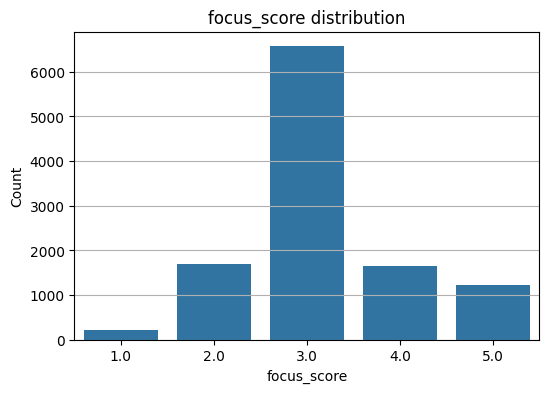

Class proportions:
focus_score
1.0    0.018
2.0    0.149
3.0    0.579
4.0    0.146
5.0    0.108
Name: proportion, dtype: float64


In [4]:
# class imbalance: focus_score 3 dominates — this is why macro F1 matters more than accuracy
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="focus_score", order=sorted(df["focus_score"].unique()))
plt.title("focus_score distribution")
plt.xlabel("focus_score")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()

print("Class proportions:")
print(df["focus_score"].value_counts(normalize=True).sort_index().round(3))

rating                1.000
temperature_count    -0.313
n_readings           -0.313
light_count          -0.313
noise_count          -0.313
humidity_count       -0.313
co2_count            -0.313
minTemp              -0.265
temperature_min      -0.265
temperature_mean     -0.264
meanTemp             -0.264
temperature_max      -0.260
maxTemp              -0.260
currentTemperature   -0.256
temperature_latest   -0.256
light_range           0.237
light_std             0.236
light_min            -0.181
light_max             0.175
co2_min              -0.153
humidity_min         -0.152
humidity_latest      -0.146
humidity_mean        -0.145
co2_latest           -0.139
co2_mean             -0.136
humidity_max         -0.131
co2_max              -0.120
noise_std             0.118
noise_max             0.111
humidity_std          0.075
noise_min             0.075
noise_mean            0.065
humidity_range        0.065
noise_range           0.060
temperature_range     0.055
co2_range           

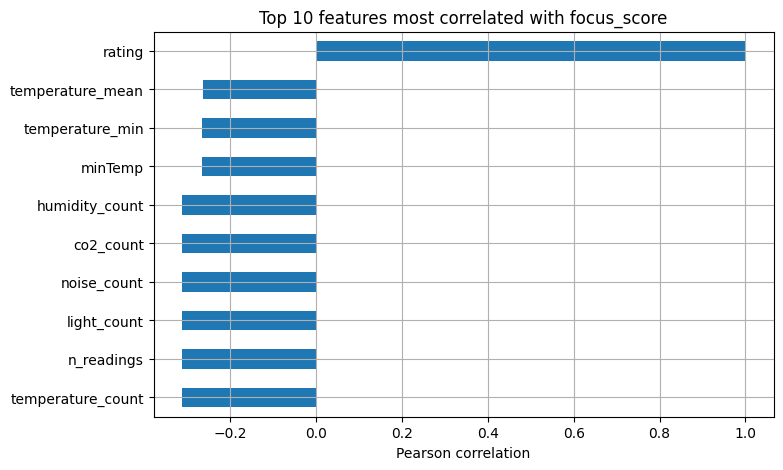

In [5]:
# which sensor features correlate most with focus_score?
corr = df.corr(numeric_only=True)["focus_score"].drop("focus_score")
corr = corr.sort_values(key=lambda x: x.abs(), ascending=False)

display(corr.round(3).rename("correlation_with_focus_score"))

plt.figure(figsize=(8, 5))
corr.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 features most correlated with focus_score")
plt.xlabel("Pearson correlation")
plt.grid()
plt.show()

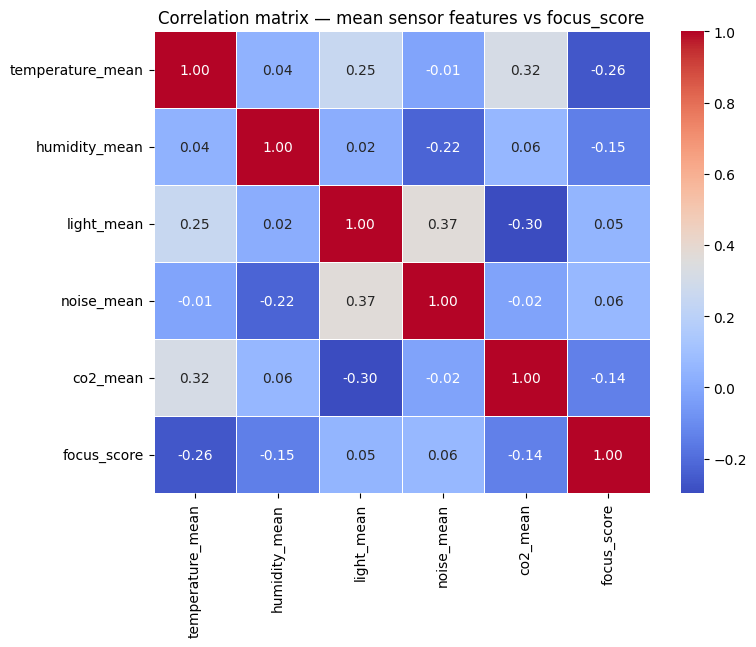

In [6]:
# correlation heatmap — mean sensor features vs focus_score
mean_features = ["temperature_mean", "humidity_mean", "light_mean", "noise_mean", "co2_mean", "focus_score"]
corr_matrix = df[mean_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix — mean sensor features vs focus_score")
plt.show()

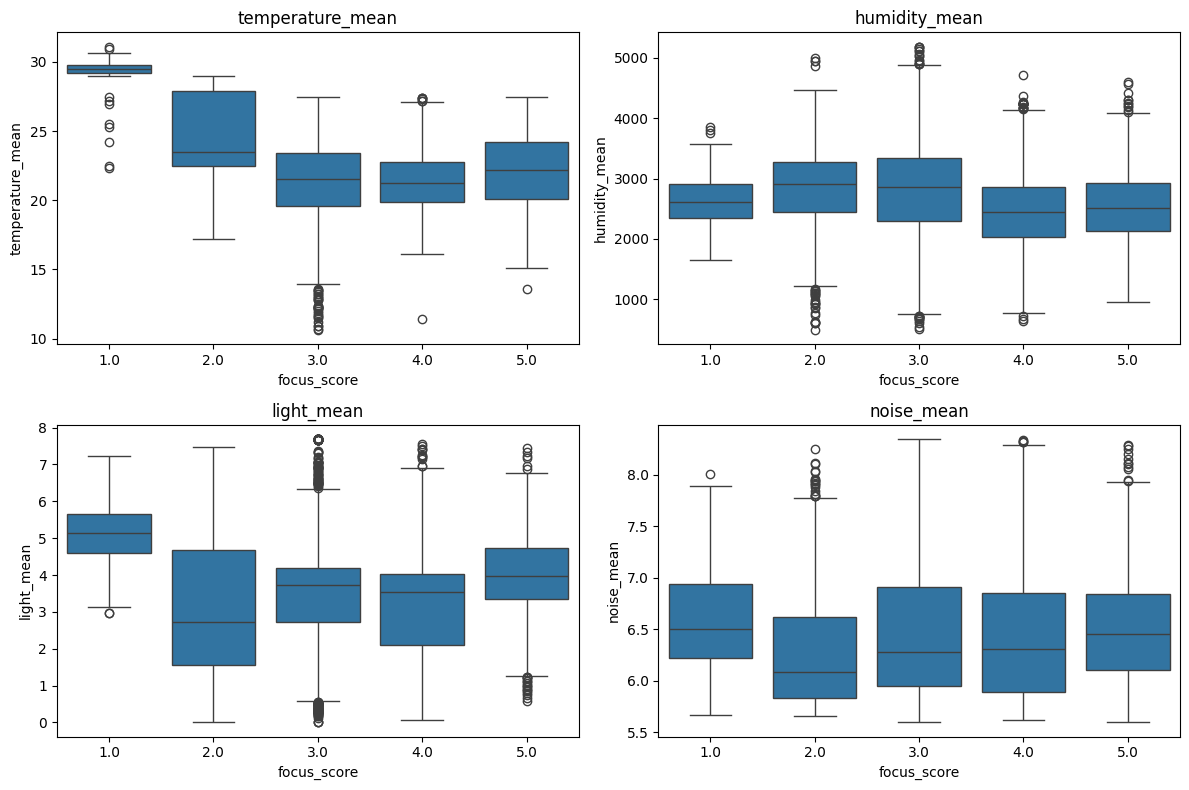

In [7]:
# do environmental conditions visually differ across focus scores?
important_features = ["temperature_mean", "humidity_mean", "light_mean", "noise_mean"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), important_features):
    sns.boxplot(data=df, x="focus_score", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("focus_score")

plt.tight_layout()
plt.show()

## Split data

In [ ]:
TARGET_COLUMN = "focus_score"

# select only numeric columns as features
X = df.drop(columns=[TARGET_COLUMN]).select_dtypes(include=[np.number])
y = df[TARGET_COLUMN]

focus_score_values = sorted(y.unique())

# split before preprocessing to avoid data leakage
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print(f"Training rows:   {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows:       {len(X_test)}")

display(pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "validation": y_val.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index()
}).fillna(0))

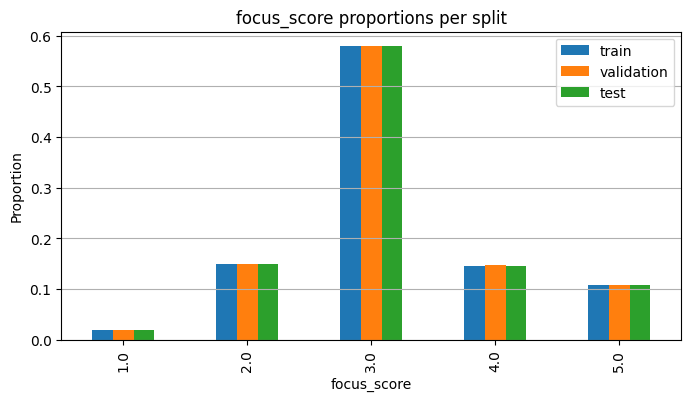

In [9]:
# verify stratification preserved class proportions across all splits
split_proportions = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
}).fillna(0)

split_proportions.plot(kind="bar", figsize=(8, 4))
plt.title("focus_score proportions per split")
plt.xlabel("focus_score")
plt.ylabel("Proportion")
plt.legend()
plt.grid(axis="y")
plt.show()

## Preprocessing

In [10]:
# logistic regression computes weighted sums of features
# features on different scales will dominate unfairly — StandardScaler is required
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Number of features: {X_train.shape[1]}")
print(f"Feature means before scaling: {X_train.mean().round(2).values[:5]} ...")
print(f"Feature means after scaling:  {X_train_scaled.mean(axis=0).round(4)[:5]} ...")

ValueError: could not convert string to float: 'smart_campus_room_measurements__lab_2_2__s00004__seg078'

## Baseline

In [ ]:
# always predict the most common focus_score — sets a floor for model quality
majority_class = y_train.mode()[0]
baseline_predictions_val = np.repeat(majority_class, len(y_val))

baseline_accuracy = accuracy_score(y_val, baseline_predictions_val)
baseline_f1 = f1_score(y_val, baseline_predictions_val, average="macro", zero_division=0)

print(f"Baseline: always predict focus_score = {majority_class}")
print(f"Baseline accuracy:  {baseline_accuracy:.3f}")
print(f"Baseline macro F1:  {baseline_f1:.3f}")

## Logistic regression

In [ ]:
# class_weight='balanced' compensates for class imbalance by up-weighting rare classes
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_train_pred = log_reg.predict(X_train_scaled)
y_val_pred = log_reg.predict(X_val_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average="macro", zero_division=0)
train_recall = recall_score(y_train, y_train_pred, average="macro", zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average="macro", zero_division=0)
val_recall = recall_score(y_val, y_val_pred, average="macro", zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

print(f"Train      - Accuracy: {train_accuracy:.2f}, Precision: {train_precision:.2f}, Recall: {train_recall:.2f}, F1: {train_f1:.2f}")
print(f"Validation - Accuracy: {val_accuracy:.2f}, Precision: {val_precision:.2f}, Recall: {val_recall:.2f}, F1: {val_f1:.2f}")

In [ ]:
# per-class breakdown: which focus scores is the model good/bad at?
print("Classification report — validation set:")
print(classification_report(y_val, y_val_pred, zero_division=0))

In [ ]:
conf_matrix = confusion_matrix(y_val, y_val_pred, labels=focus_score_values)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=focus_score_values, yticklabels=focus_score_values)
plt.xlabel("Predicted focus_score")
plt.ylabel("Actual focus_score")
plt.title("Confusion matrix — validation set")
plt.show()

In [ ]:
# visualize precision, recall and F1 per class to understand where the model struggles
report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)
class_metrics = pd.DataFrame({
    str(cls): {
        "precision": report[str(cls)]["precision"],
        "recall": report[str(cls)]["recall"],
        "f1-score": report[str(cls)]["f1-score"]
    }
    for cls in focus_score_values
}).T

class_metrics.plot(kind="bar", figsize=(10, 5))
plt.title("Per-class precision, recall and F1 — validation set")
plt.xlabel("focus_score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.grid(axis="y")
plt.show()

In [ ]:
# ROC curves: one per class using One-vs-Rest strategy
# AUC > 0.5 means better than random; AUC = 1.0 is perfect
y_val_bin = label_binarize(y_val, classes=focus_score_values)
y_val_scores = log_reg.predict_proba(X_val_scaled)

plt.figure(figsize=(8, 6))
for i, cls in enumerate(focus_score_values):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_val_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"focus_score {cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # dashed diagonal = random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (One-vs-Rest) — validation set")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
# precision-recall curves: more informative than ROC when classes are imbalanced
plt.figure(figsize=(8, 6))
for i, cls in enumerate(focus_score_values):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_scores[:, i])
    plt.plot(recall, precision, marker=".", label=f"focus_score {cls}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (One-vs-Rest) — validation set")
plt.legend(loc="upper right")
plt.grid()
plt.show()

## Regularization

`C` is the inverse regularization strength. Small `C` = strong regularization (simpler model). Large `C` = weak regularization (model fits training data more closely).

In [ ]:
c_results = []

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42, C=C)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_val_scaled)

    c_results.append({
        "C": C,
        "val_accuracy": accuracy_score(y_val, predictions),
        "val_macro_f1": f1_score(y_val, predictions, average="macro", zero_division=0)
    })

c_results_df = pd.DataFrame(c_results)
display(c_results_df.round(3))

plt.figure(figsize=(8, 5))
plt.plot(c_results_df["C"], c_results_df["val_accuracy"], marker="o", label="accuracy")
plt.plot(c_results_df["C"], c_results_df["val_macro_f1"], marker="o", label="macro F1")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Score")
plt.title("Effect of C on validation performance")
plt.legend()
plt.grid()
plt.show()

## Feature coefficients

Logistic regression learns one set of coefficients per class. The mean absolute coefficient across all classes shows which features the model relies on most overall.

In [ ]:
# mean absolute coefficient per feature across all classes
mean_abs_coef = np.abs(log_reg.coef_).mean(axis=0)
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Mean Absolute Coefficient": mean_abs_coef
}).sort_values("Mean Absolute Coefficient", ascending=False)

plot_data = coef_df.head(15).sort_values("Mean Absolute Coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_data["Feature"], plot_data["Mean Absolute Coefficient"])
ax.set_xlabel("Mean absolute coefficient")
ax.set_title("Top 15 most influential features (mean absolute coefficient across all classes)")
ax.grid(axis="x")
plt.tight_layout()
plt.show()

## Evaluation on test set

In [ ]:
# pick best C from validation results, retrain on full train_val set
best_C = c_results_df.sort_values("val_macro_f1", ascending=False).iloc[0]["C"]
print(f"Best C based on validation macro F1: {best_C}")

# refit scaler on the larger train_val set before final test evaluation
scaler_final = StandardScaler()
X_train_val_scaled = scaler_final.fit_transform(X_train_val)
X_test_scaled_final = scaler_final.transform(X_test)

final_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42, C=best_C)
final_model.fit(X_train_val_scaled, y_train_val)

y_test_pred = final_model.predict(X_test_scaled_final)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

print(f"Test - Accuracy: {test_accuracy:.2f}, Precision: {test_precision:.2f}, Recall: {test_recall:.2f}, F1: {test_f1:.2f}")
print()
print("Classification report — test set:")
print(classification_report(y_test, y_test_pred, zero_division=0))

In [ ]:
conf_matrix_test = confusion_matrix(y_test, y_test_pred, labels=focus_score_values)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=focus_score_values, yticklabels=focus_score_values)
plt.xlabel("Predicted focus_score")
plt.ylabel("Actual focus_score")
plt.title("Confusion matrix — test set")
plt.show()

In [ ]:
# compare train, validation and test metrics side by side
metrics_df = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "Accuracy": [train_accuracy, val_accuracy, test_accuracy],
    "Precision": [train_precision, val_precision, test_precision],
    "Recall": [train_recall, val_recall, test_recall],
    "F1 Score": [train_f1, val_f1, test_f1]
})
metrics_melted = metrics_df.melt(id_vars="Set", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(x="Set", y="Score", hue="Metric", data=metrics_melted)
plt.title("Performance metrics — train, validation and test sets")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.show()

## Conclusion

Logistic regression was applied to predict `focus_score` (1–5) from 35 environmental sensor features.

The dataset is heavily imbalanced: `focus_score` 3 dominates with ~48% of rows, while scores 1 and 5 are rare. Because of this, accuracy alone is misleading — the baseline model (always predict 3) already achieves ~48% accuracy with macro F1 of only ~0.13. Macro F1 is therefore the primary evaluation metric throughout.

Using `class_weight='balanced'` forces the model to pay equal attention to all five classes during training, which significantly improves recall on rare classes at the cost of some overall accuracy.

The ROC and precision-recall curves show the model distinguishes extreme scores (1 and 5) better than middle scores (2, 3, 4), which are naturally harder to separate from each other. The confusion matrix confirms most errors are between adjacent scores.

The regularization analysis shows performance is relatively stable across C values, which suggests the model is not strongly overfitting and that the linear decision boundary is a reasonable fit for this data.

The feature coefficient plot reveals which environmental sensors the model relies on most. Features with high mean absolute coefficients are the ones that most consistently push the predicted class one way or another.

Logistic regression is a solid linear baseline. Its limitations here are:
- Assumes a linear relationship between features and log-odds, which may not hold for environmental data
- Many features are highly correlated (min/max/mean of the same sensor), which can make individual coefficients unstable
- Even with class weighting, rare classes (1 and 5) are difficult to predict reliably with limited examples
